<a href="https://colab.research.google.com/github/javendaXgh/ucveconomiaestadistica1/blob/main/notebooks/laboratorio_3_tarea_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadística I, Laboratorio 3 y Tarea 6

## Indique su nombre y cédula

### Nombre:

### Cédula:



## Temas a abordar:

### Números índices
- Índice simple: Mide el cambio individual de cada precio respecto al período base.
- Índice agregado simple: Compara el promedio de precios en distintos períodos, sin ponderar por cantidades.
- Índice agregado ponderado de Laspeyres: Usa cantidades del período base para ponderar precios. Tiende a sobreestimar el aumento del costo de vida.
- Índice agregado ponderado de Paasche: Usa cantidades actuales, reflejando sustitución de bienes. Tiende a subestimar el aumento del costo de vida.



### Series de Tiempo:
Análisis de series de tiempo

In [ ]:
# cargar librerías a usar
library(ggplot2)
library(dplyr)

#### Definir los bienes y servicios


In [ ]:
# usar la función c() de R
c("Arroz", "Carne", "Transporte", "Medicina", "Educacion")

#### Definir precios para cada producto


In [ ]:
c(2.5, 5.0, 1.2, 3.0, 4.5) # período base
c(3.0, 5.5, 1.3, 3.5, 4.8) # precios período 1
c(3.2, 6.0, 1.4, 3.4, 5.2) # precios período 2

#### Crear una estructura donde se almacenen los datos
La estructura se crea con una función que se llama data.frame que se llama datos_precios

In [ ]:
# Simulación de datos de precios
datos_precios = data.frame(
  Bien = c("Arroz", "Carne", "Transporte", "Medicina", "Educacion"), # bienes y servicios
  P0 = c(2.5, 5.0, 1.2, 3.0, 4.5),   # Precios en período base
  P1 = c(3.0, 5.5, 1.3, 3.5, 4.8),   # Precios en período 1
  P2 = c(3.2, 6.0, 1.4, 3.4, 5.2)    # Precios en período 2
)


In [ ]:
datos_precios

Vamos a signar las cantidades consumidas para cada bien o servicio en el período base:

1- arroz: 10 unidades

2- carne: 8 unidades

3- transporte: 15 pasajes

4- medicina: 6 unidades

5- Educacion: 4 unidades crédito

Lo mismo se define para otros dos períodos en `cantidades_1` y  `cantidades_2`


In [ ]:
# Cantidades base (para índices ponderados)
cantidades_base <- c(10, 8, 15, 6, 4) # la letra c indica que es un vector

# Cantidades actuales (para Paasche)
cantidades_1 <- c(9, 8, 16, 5, 5)
cantidades_2 <- c(8, 7, 18, 6, 6)

In [ ]:
cantidades_base
cantidades_1
cantidades_2

In [ ]:
# Agregamos las cantidades al dataframe
# se usa la letra Q que viene de cantidades en inglés (quantities)
datos_precios$Q0 = cantidades_base # $Q0 se usa para crear una nueva columna
datos_precios$Q1 = cantidades_1 # $Q1 se crea otra columna  en datos_precios
datos_precios$Q2 = cantidades_2 # $Q2 se crea otra columna en datos_precios

Revisar la nueva data frame con todos los datos de interés

In [ ]:
datos_precios

### Cálcular Índice Simple

In [ ]:
# crear la nueva data frame en la que mostraremos el índice simple
# obviar a nive de codigos

indice_simple <- datos_precios[ , c("Bien", "P0", "P1", "P2")]
indice_simple

**¿Cómo calcularíamos el índice simple para el período 1? mediante el operador $ insertamos una columna nueva**

In [ ]:
# paso a paso
indice_simple$P1 #precios período 1
indice_simple$P0 #precios período base
indice_simple$P1/indice_simple$P0 # opera dividiendo cada valor de P1 entre cada valor de P0 según la posición

In [ ]:
indice_simple$I_Simple_01 = indice_simple$P1/indice_simple$P0

indice_simple

**y para el período 2?**

In [ ]:
indice_simple$I_Simple_02 = indice_simple$P2/indice_simple$P0

indice_simple

#### ejercicio tarea:
1- Modificar cada uno de los índices y colocarlos en terminos porcentuales

2- Calcular la variación por entre período 1 y 2 colocarlo en una nueva columna de indice_simple

### Índice Agregado Simple

In [ ]:
datos_precios$P0 # precios periodo 0
datos_precios$P1 # precios periodo 1
sum(datos_precios$P1) # ver suma de productos en período 1

sum(datos_precios$P0)# ver suma de productos en período base

In [ ]:
# ---- ÍNDICE AGREGADO SIMPLE ----

# Suma de precios en cada periodo dividido por la suma del período base
I_agregado_simple_01 <- sum(datos_precios$P1) / sum(datos_precios$P0)
I_agregado_simple_01 # valor del índice simple
I_agregado_simple_01*100 # valor del índice simple en términos porcentuales

In [ ]:
# ---- ÍNDICE AGREGADO SIMPLE ----
# Suma de precios en cada periodo dividido por la suma del período base
I_agregado_simple_02 <- sum(datos_precios$P2) / sum(datos_precios$P0)
round(I_agregado_simple_02*100, 2) #aproximo el número mediante la función round

### ÍNDICE AGREGADO PONDERADO LASPEYRES

fórmula = Σ P1 * Q0 / Σ P0 * Q0

In [ ]:
datos_precios

### Paso a paso antes de obtener valores

In [ ]:
# (Σ P1*Q0) / (Σ P0*Q0)
datos_precios$P1 * datos_precios$Q0 # multiplicacion de cada precio periodo 1 por cantidades periodo base 0
sum(datos_precios$P1 * datos_precios$Q0) # numerador de la fórmula (Σ P1*Q0) de Laspeyres
datos_precios$P0 * datos_precios$Q0 # multiplicacion de cada precio periodo base por cantidades periodo base 0
sum(datos_precios$P0 * datos_precios$Q0) # denominador de la formula (Σ P0*Q0)
sum(datos_precios$P1 * datos_precios$Q0) / sum(datos_precios$P0 * datos_precios$Q0) # resultado
round(sum(datos_precios$P1 * datos_precios$Q0) / sum(datos_precios$P0 * datos_precios$Q0) , 2) # redondear el resultado anterior

In [ ]:
# asignar a  I_laspeyres_01 el resultado período 1
I_laspeyres_01 <- sum(datos_precios$P1 * datos_precios$Q0) / sum(datos_precios$P0 * datos_precios$Q0)

# asignar a  I_laspeyres_02 el resultado período 2
I_laspeyres_02 <- sum(datos_precios$P2 * datos_precios$Q0) / sum(datos_precios$P0 * datos_precios$Q0)

In [ ]:
# Revisar los valores del índice de Laspeyres
cat("Período 1 vs base:", round(I_laspeyres_01, 2), "\n")
cat("Período 2 vs base:", round(I_laspeyres_02, 2), "\n")

### ÍNDICE AGREGADO PONDERADO PAASCHE

fórmula = Σ P1 * Q1 / Σ P0 * Q1

In [ ]:
# (Σ P1*Q1) / (Σ P0*Q1)
I_paasche_01 <- sum(datos_precios$P1 * datos_precios$Q1) / sum(datos_precios$P0 * datos_precios$Q1)
I_paasche_02 <- sum(datos_precios$P2 * datos_precios$Q2) / sum(datos_precios$P0 * datos_precios$Q2)

In [ ]:
cat("Período 1 vs base:", round(I_paasche_01, 3), "\n")
cat("Período 2 vs base:", round(I_paasche_02, 3), "\n")

#### ejercicio tarea:
3- hacer Paso a paso de paashe, según paso a paso que se muestra Laspeyre

### Series de Temporales
#### Ejemplo 1: producción de petróleo Venezuela-Colombia

In [ ]:
# cargar datos
# fuente de los datos, Our World in Data
prod_petroleo = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/producion_petroleo.csv')

In [ ]:
prod_petroleo

In [ ]:
ggplot(prod_petroleo,aes(x=Year,
                         y=produccionK,
                         color= Entity ))+
  geom_line()

#### Ejemplo 2: valor apple

In [ ]:
# cargar datos de valores de cierre diario de acción apple para período 2021-2025
df_valor_apple = read.csv('https://raw.githubusercontent.com/javendaXgh/ucveconomiaestadistica1/refs/heads/main/data/df_valor_apple.csv')%>%
  as_tibble()%>%
  mutate(fecha= as.Date(fecha))

In [ ]:
# revisar valores
head(df_valor_apple)

#### Visualizar los movimientos de las acción año a año

In [ ]:
ggplot(df_valor_apple,
       aes(x=dia,
           y=AAPL.close,
           color=factor(year)))+
  geom_line()+
  geom_smooth() # permite ver la serie suavizada y es recomendable para visualizar tendencias

In [ ]:
ggplot(df_valor_apple,
       aes(x=fecha,
           y=AAPL.close))+
  geom_line()+
  geom_smooth()


#### Visualizar los movimientos de las acción durante todo el período

### Ejercicio:
Identificar en al menos un gráficos representados anteriormente, cada uno de los siguientes compomentes visuales:

-   **Tendencia**: dirección general a largo plazo.

-   **Estacionalidad**: patrones repetitivos dentro de un período fijo.

-   **Ciclicidad**: ondulaciones de mayor duración.

-   **Aleatoriedad**: fluctuaciones irregulares.

Puede hacer captures de pantalla de un área del gráfico que en particular esté analizando y subirlos al notebook añadiendo una celda de texto con su correspondiente análisis.



Ejemplo:


se observa que para la siguiente imagen de apple en el año tal, en los días tal .....



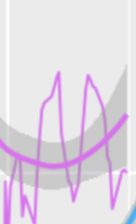


hay una subida y bla, bla, bla